# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Margareta Lola Lali Lulita
- Email: margaretalolalilulita@gmail.com
- Id Dicoding: margaretalola

## Persiapan

### Menyiapkan library yang dibutuhkan

Melakukan import library dan setting environtment terlebih dahulu

In [ ]:
!pip install --upgrade scikit-learn

In [1]:
import pandas as pd
import numpy as np
from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### Menyiapkan data yang akan diguankan

Dataset diambil dari https://github.com/dicodingacademy/dicoding_dataset/tree/f4a7541bc3dfca0012e20778e135c03b3e76dc67/employee

Dataset ini berisi berbagai metrik terkait demografi dan pekerjaan karyawan termasuk apakah mereka pergi dari perusahaan, tingkat kepuasan kerja, tingkat pengalaman kerja, dan faktor lainnya yang dapat mempengaruhi retensi karyawan. 

## Data Understanding

Pada Data Understanding, ada beberapa temuan:

- Terdapat 1470 entries dengan 35 features
- Tidak ada indikasi duplikasi dalam database
- Terdapat 412 missing value
- Terdapat indikasi outlier
- Terdapat 100++ karyawan yang attrition

Dalam proses ini lebih banyak menggunakan library pandas untuk memahami dataset. 

Informasi setiap feature pada dataset employee terlampir di bawah ini:
- EmployeeId - Employee Identifier
- Attrition - Did the employee attrition? (0=no, 1=yes)
- Age - Age of the employee
- BusinessTravel - Travel commitments for the job
- DailyRate - Daily salary
- Department - Employee Department
- DistanceFromHome - Distance from work to home (in km)
- Education - 1-Below College, 2-College, 3-Bachelor, 4-Master,5-Doctor
- EducationField - Field of Education
- EnvironmentSatisfaction - 1-Low, 2-Medium, 3-High, 4-Very High
- Gender - Employee's gender
- HourlyRate - Hourly salary
- JobInvolvement - 1-Low, 2-Medium, 3-High, 4-Very High
- JobLevel - Level of job (1 to 5)
- JobRole - Job Roles
- JobSatisfaction - 1-Low, 2-Medium, 3-High, 4-Very High
- MaritalStatus - Marital Status
- MonthlyIncome - Monthly salary
- MonthlyRate - Mounthly rate
- NumCompaniesWorked - Number of companies worked at
- Over18 - Over 18 years of age?
- OverTime - Overtime?
- PercentSalaryHike - The percentage increase in salary last year
- PerformanceRating - 1-Low, 2-Good, 3-Excellent, 4-Outstanding
- RelationshipSatisfaction - 1-Low, 2-Medium, 3-High, 4-Very High
- StandardHours - Standard Hours
- StockOptionLevel - Stock Option Level
- TotalWorkingYears - Total years worked
- TrainingTimesLastYear - Number of training attended last year
- WorkLifeBalance - 1-Low, 2-Good, 3-Excellent, 4-Outstanding
- YearsAtCompany - Years at Company
- YearsInCurrentRole - Years in the current role
- YearsSinceLastPromotion - Years since the last promotion
- YearsWithCurrManager - Years with the current manager



### Load Dataset

Melakukan pembacaan terhadap dataset menggunakan library pandas

In [2]:
# Tampilkan dataset 5 teratas - penggunaan library pandas
df = pd.read_csv('/kaggle/input/employee-data/employee_data.csv')
df.head(5)

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


### Cek dimensi data
Dalam cek dimensi data, digunakan df.shape untuk melihat dimensinya. Dimensi dari dataset yang akan diolah adalah 1470 x 35 feature

In [3]:
# Dimensi data
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")

Jumlah baris: 1470, Jumlah kolom: 35


### Cek informasi dataset
Dalam step ini akan dilihat lebih lanjut terkait struktur dataframe, termasuk jumlah baris dan kolom, tipe data setiap kolom, dan jumlah value yang ada dalam setiap features.

In [4]:
# Menampilkan informasi terkait dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

### Cek nilai null atau missing value
Dalam tahap ini, missing value atau nilai null yang ada dalam dataset dicheck untuk masing - masing kolom. Berdasarkan hasil temuan, didapatkan 412 kolom yang mengindikasikan kosong dan nanti akan ditangani dengan melakukan penghapusan kolom karena missing value belum melebihi 30% dari total entry yang ada

In [5]:
# Cek nilai null atau missing value dalam dataset
df.isna().sum()

EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance               0
YearsAtC

In [6]:
missing_ratio = (412 / 1470) * 100
print(f"Proporsi Missing: {missing_ratio:.2f}%")

Proporsi Missing: 28.03%


### Cek duplikasi dalam dataframe
Melakuakan cek terhadap dataframe untuk melihat apakah terdapat nilai yang duplikat atau tidak

In [7]:
# Cek total nilai duplikat
df.duplicated().sum()

0

### Cek nilai statistik
Menggunakan `.describe()` untuk melihat informasi statistik kolom yang berindikasi numerik dalam dataframe

* Count – Jumlah total nilai yang tersedia (tidak termasuk NaN).
* Mean – Nilai rata-rata dari setiap kolom numerik.
* Std – Standar deviasi, menunjukkan seberapa tersebar data.
* Min – Nilai terkecil dalam dataset.
* 25% (Q1) – Kuartil pertama, menunjukkan batas bawah 25% data.
* 50% (Median) – Kuartil kedua, menunjukkan nilai tengah data.
* 75% (Q3) – Kuartil ketiga, menunjukkan batas atas 75% data.
* Max – Nilai terbesar dalam dataset

In [8]:
# Cek informasi stastistik terkait database menggunakn .describe()
df.describe()

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### Cek dan Visualisasi Outlier
Memisahkan kolom numerik terlebih dahulu dan disimpan dalam `df_numeric` menggunakan `.copy` dengan parameter `.select_dtypes(exclude=['object']` dan lakukan visualisai dengan bantuan library matplotlib dan seaborn.

Berdasarkan hasil temuan, terdapat indikasi outlier pada column MonthlyIncome, TotalWorkingYears, TrainingTimesLastYear, YearsSinceLastPromotion, YearsAtCompany, YearsInCurrentRole, dan YearsWithCurrManager, yang nantinya akan ditangani pada tahap data preparation

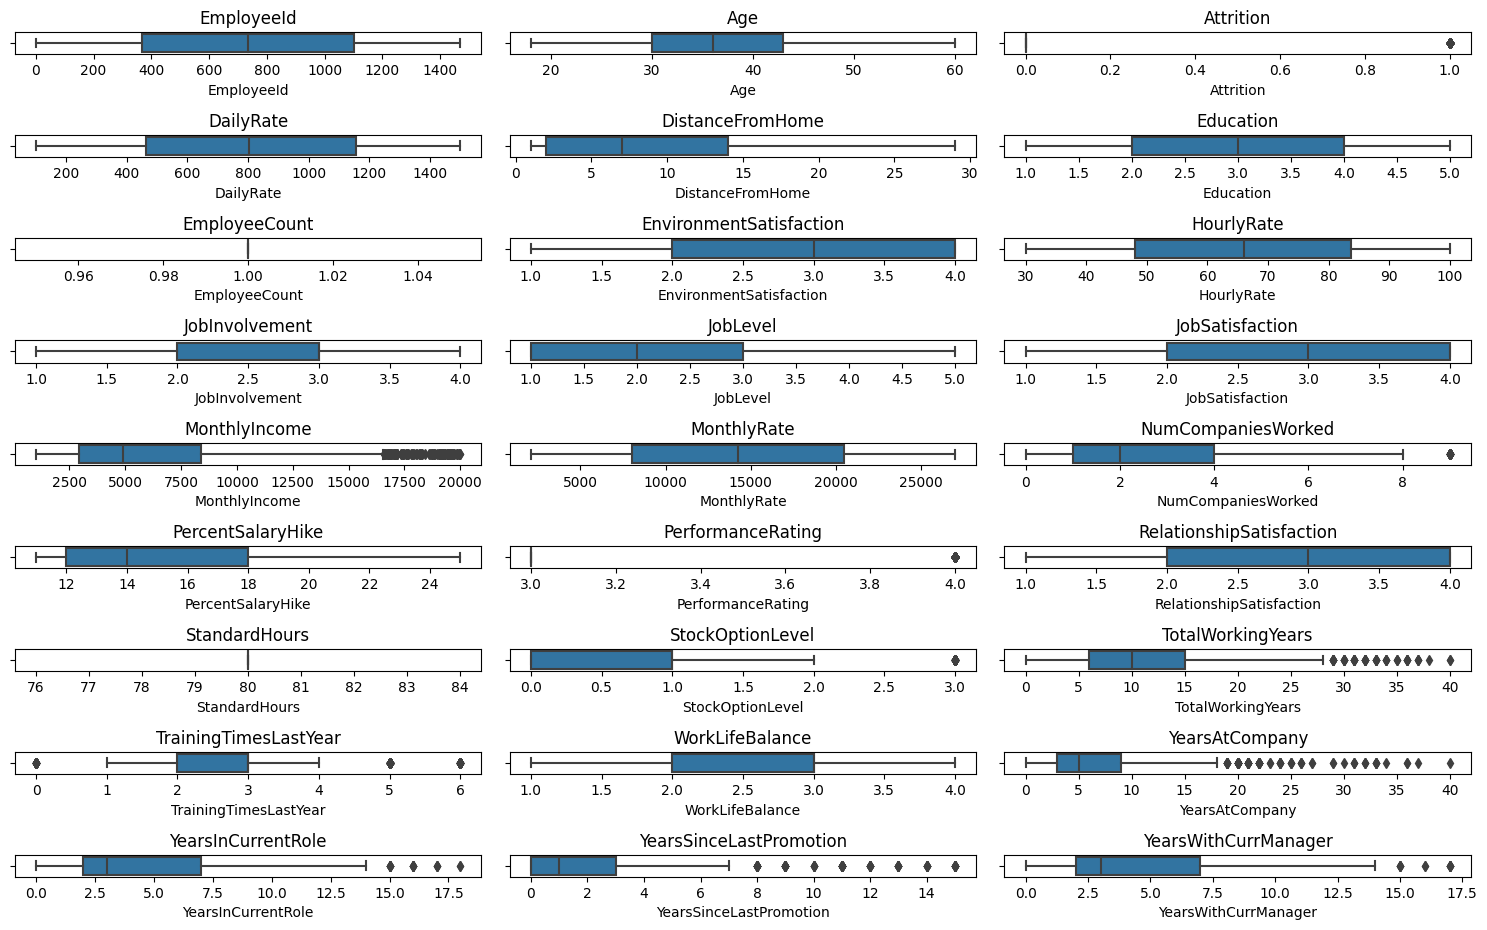

In [9]:
# Cek outlier - Visualisasi
df_numeric = df.select_dtypes(exclude=['object']).copy()
plt.figure(figsize=(15, 10))

for i, feature in enumerate(df_numeric.columns, 1):
    plt.subplot((len(df_numeric.columns) // 3) + 1, 3, i) 
    sns.boxplot(x=df_numeric[feature]) 
    plt.title(feature)

plt.tight_layout()
plt.show()

### Perbandingan jumlah employee yang ada saat ini dengan total (employee) attrition 
Untuk visualisasi terhadap distribusi attrition rate, digunakan rumus perhitungan terlebih dahulu yaitu mencari persentase dari total pegawai yang ada saat ini dengan pegawai yang memutuskan untuk attrition. 

dengan rumus:
`(attrition_yes / total_employee) * 100`

attrition_yes = total nilai dalam kolom attrition yang bernilai 1.0
total_employee = total dari pegawai yang ada berdasarkan EmployeeId 

Visualisasi menggunakan bantuan library matplotlib dan seaborn. Dengan temuan hasil attrition rate berada diangka **12.18%**

Attrition Rate: 12.18%


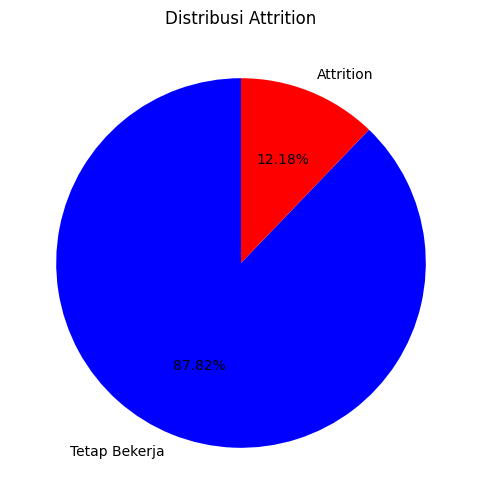

In [10]:
attrition_yes = df[df["Attrition"] == 1]["Attrition"].count()
total_employees = df["EmployeeId"].count()
attrition_rate = (attrition_yes / total_employees) * 100
print(f"Attrition Rate: {attrition_rate:.2f}%")

labels = ["Tetap Bekerja", "Attrition"]
sizes = [100 - attrition_rate, attrition_rate]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%.2f%%", colors=["blue", "red"], startangle=90)
plt.title("Distribusi Attrition")
plt.show()


### Monthly Income dengan attrition
Dalam melihat keterhubungan dalam monthly income dengan attrition, didapatkan beberapa temuan seperti di bawah ini:
1. Karyawan yang masih aktif memiliki pendapatan bulanan yang lebih tinggi dibandingkan dengan karyawan yang keluar (attrition).
2. Variasi pendapatan lebih besar pada karyawan yang tetap bekerja, terlihat dari rentang interquartile yang lebih luas.
3. Ada beberapa outlier, terutama pada kelompok karyawan yang masih aktif, menunjukkan ada individu dengan pendapatan jauh di atas rata-rata.
4. Variansi gaji dengan rentang `$1000 - $3000` memiliki tingkat attrition yang tinggi, terutama yang berada dalam rentang $ 2500

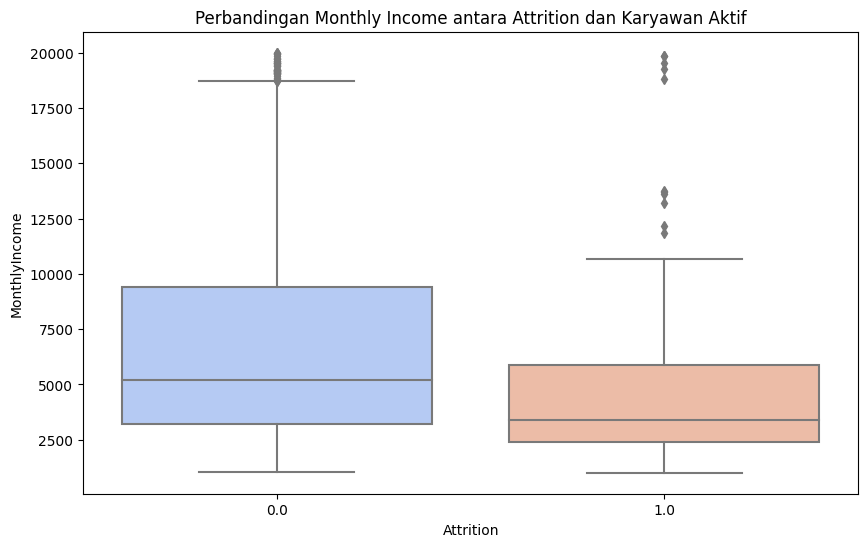

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df, palette="coolwarm")
plt.title("Perbandingan Monthly Income antara Attrition dan Karyawan Aktif")
plt.show()

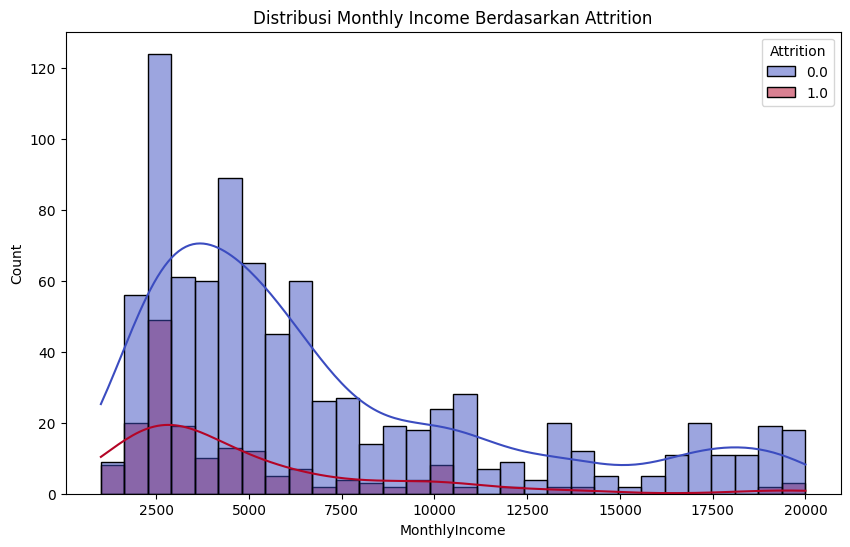

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(df, x="MonthlyIncome", hue="Attrition", bins=30, kde=True, palette="coolwarm")
plt.title("Distribusi Monthly Income Berdasarkan Attrition")
plt.show()

### Worklife balance dengan Attrition 

Dalam melihat hubungan work-life balance dengan attrition didapatkan beberapa temuan yaitu:
1. Karyawan dengan Work-Life Balance tingkat 1 (low) memiliki kemungkinan lebih tinggi untuk keluar dari perusahaan.
2. Sebaliknya, mayoritas karyawan dengan Work-Life Balance tingkat 3 (Excellent) atau 4 (Outstanding) tetap bertahan.

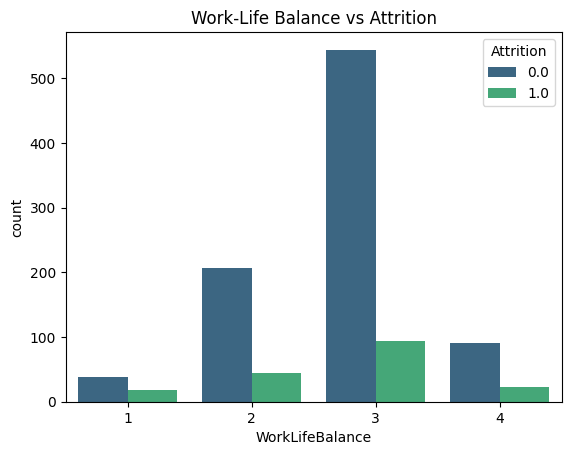

In [13]:
sns.countplot(x="WorkLifeBalance", hue="Attrition", data=df, palette="viridis")
plt.title("Work-Life Balance vs Attrition")
plt.show()

### Job Satisfaction dengan Attrition
Dalam melihat hubungan job satisfaction dengan attrition didapatkan beberapa temuan yaitu:
1. Karyawan dengan Job Satisfaction tingkat 3 (high) dan 4 (very high) lebih banyak bertahan dibandingkan mereka yang memiliki Job Satisfaction tingkat 1 (low) dan 2 (medium).
2. Ada indikasi bahwa kepuasan kerja rendah meningkatkan kemungkinan attrition.

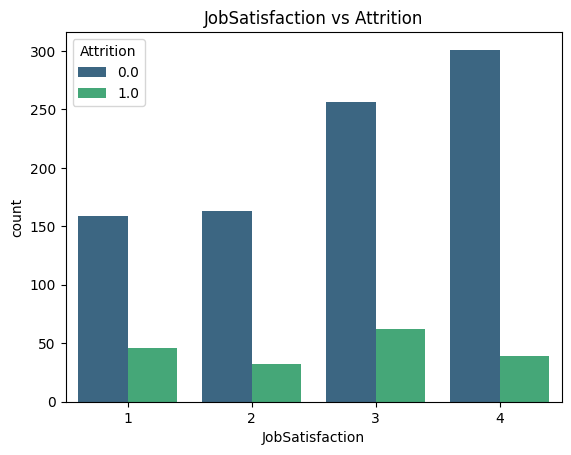

In [14]:
sns.countplot(x="JobSatisfaction", hue="Attrition", data=df, palette="viridis")
plt.title("JobSatisfaction vs Attrition")
plt.show()

## Data Preparation / Preprocessing

### Handling missing value
Menghapus missing value dengan `.dropna()` sehingga data lebih bersih dan siap dianalisis

In [15]:
# Hapus nilai null
df.dropna(inplace=True)
print(f"Data setelah cleaning: {len(df)}")

Data setelah cleaning: 1058


### Menghapus fitur 
Menghapus beberapa kolom tertentu terutama yang tidak digunakan selama proses permodelan atau kolom yang tidak memiliki arti dari DataFrame menggunakan pustaka pandas dalam Python

In [16]:
# Hapus fitur 
df = df.drop(['EmployeeId', 'Over18', 'StandardHours'], axis=1)

### Handling Outlier
Melakukan visualisasi terhadap outlier terlebih dahulu

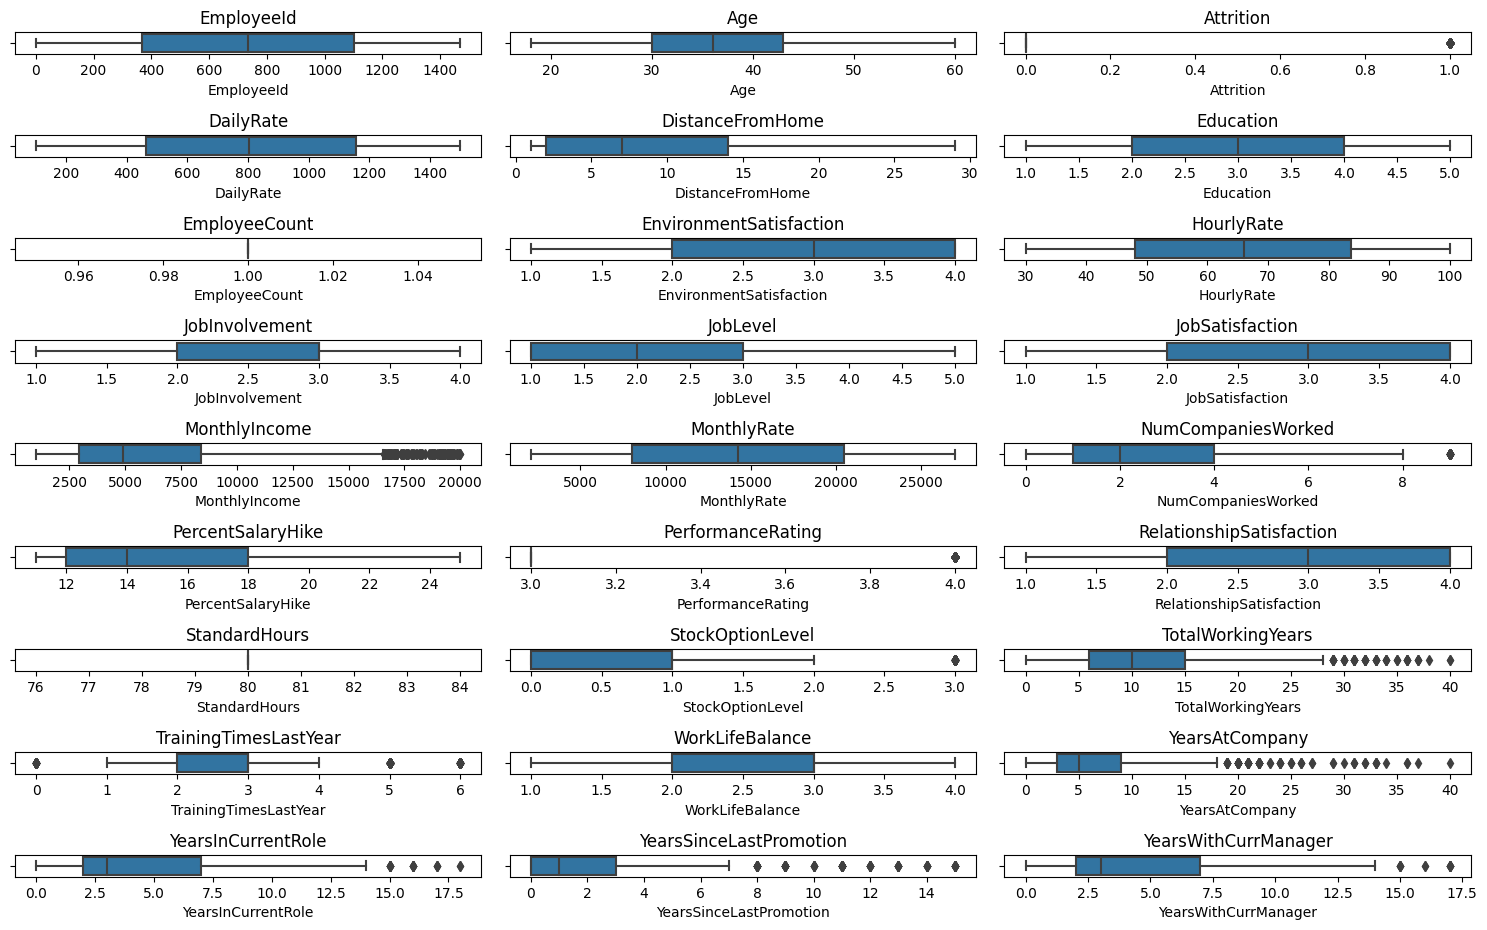

In [17]:
# Handling Outlier
plt.figure(figsize=(15, 10))

for i, feature in enumerate(df_numeric.columns, 1):
    plt.subplot((len(df_numeric.columns) // 3) + 1, 3, i) 
    sns.boxplot(x=df_numeric[feature]) 
    plt.title(feature)

plt.tight_layout()
plt.show()

Setelah visualisasi, akan dilakukan Winsorizing pada beberapa fitur numerik dalam dataset untuk menangani outlier. Winsorizing menggantikan nilai ekstrem dengan persentil tertentu (dalam hal ini 5% terbawah dan 5% teratas), sehingga outlier tidak terlalu berpengaruh pada analisis. Sebelum itu, pastikan membuat salinan terhadap data asli terlebih dahulu untuk mencegah kehilangan informasi dan perubahan permanen

Selanjutnya melakukan visualisasi setelah membenahi outlier

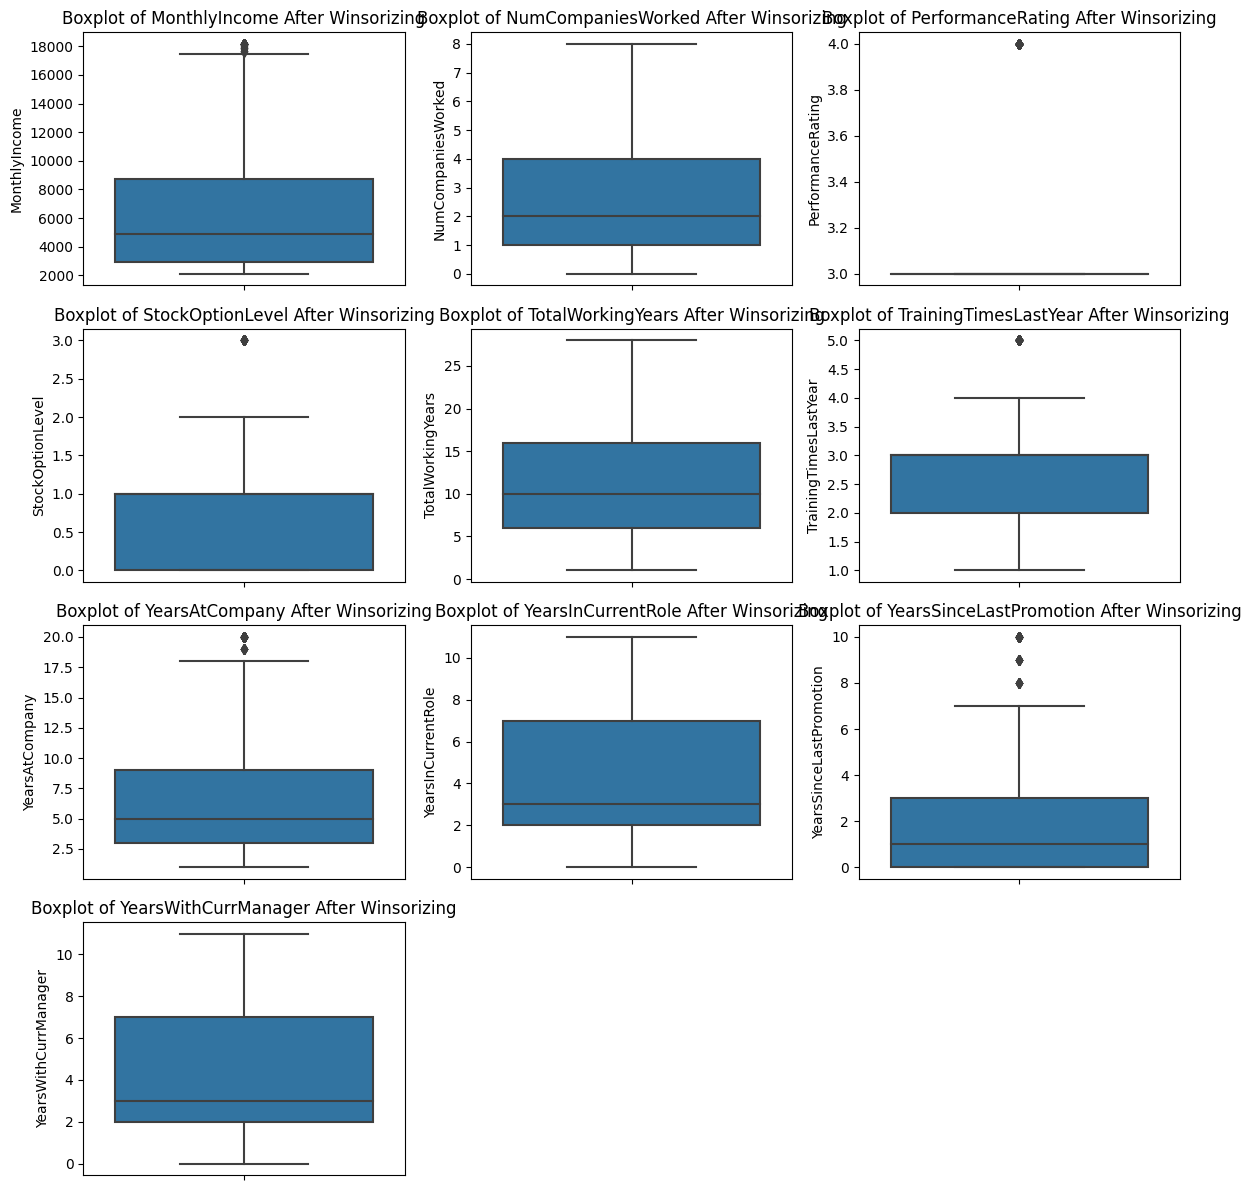

In [18]:
# Buat salinan dataset sebelum perubahan
df_winsorized = df.copy()

# Winsorizing selected columns
winsorized_columns = ['MonthlyIncome', 'NumCompaniesWorked',  
                      'PerformanceRating', 'StockOptionLevel', 
                      'TotalWorkingYears', 'TrainingTimesLastYear', 
                      'YearsAtCompany', 'YearsInCurrentRole', 
                      'YearsSinceLastPromotion', 'YearsWithCurrManager']

for col in winsorized_columns:
    df_winsorized[col] = winsorize(df_winsorized[col], limits=[0.05, 0.05])  # Winsorizing 5% atas & bawah

# Visualisasi dengan Boxplot
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(12, 12))  
axes = axes.flatten()

# Loop sesuai jumlah kolom numerik agar tidak terjadi error
for i in range(len(winsorized_columns)):
    sns.boxplot(y=df_winsorized[winsorized_columns[i]], ax=axes[i])
    axes[i].set_title(f'Boxplot of {winsorized_columns[i]} After Winsorizing')

# Sembunyikan subplot yang tidak terpakai
for j in range(len(winsorized_columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [19]:
df_winsorized

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,1,...,3,1,0,15,2,1,1,0,0,0
2,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,1,...,3,3,3,18,2,4,10,0,2,7
3,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,3,...,3,4,1,23,2,4,20,4,4,8
6,40,0.0,Travel_Rarely,1124,Sales,1,2,Medical,1,2,...,4,3,3,6,2,2,4,3,0,2
7,55,1.0,Travel_Rarely,725,Research & Development,2,3,Medical,1,4,...,3,4,1,24,2,3,5,2,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1464,28,1.0,Non-Travel,1366,Research & Development,24,2,Technical Degree,1,2,...,3,1,0,10,2,2,10,7,1,9
1465,38,0.0,Travel_Rarely,168,Research & Development,1,3,Life Sciences,1,3,...,3,4,0,10,4,4,1,0,0,0
1467,28,1.0,Travel_Rarely,1485,Research & Development,12,1,Life Sciences,1,3,...,3,4,0,1,4,2,1,1,0,0
1468,40,0.0,Non-Travel,458,Research & Development,16,2,Life Sciences,1,3,...,3,2,1,6,1,3,4,2,0,0


### Label Encoding
Melakukan pelabelan encoding pada beberapa kolom kategori ordinal dalam sebuah datafram menggunakan `LabelEncoder` dari sklearn. Label encoding akan mengonversi nilai kategori menjadi angka agar dapat digunakan dalam analisis atau pemodelan machine learning.

Pada tahapan ini, untuk menghindari perubahan permanen dilakukan copy dataframe hasil dari handling outlier terlebih dahulu. Lalu, menentukan kolom ordinal yang akan dikonversi untuk diaplikasikan LabelEncoder

In [20]:
# Buat salinan sebelum melakukan encoding
df_encoded = df_winsorized.copy()

# Label Encoding untuk kategori ordinal
label_cols = ['Attrition', 'Education', 'EnvironmentSatisfaction', 'JobInvolvement',
              'JobLevel', 'JobSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance']

le = LabelEncoder()
for col in label_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [21]:
df_encoded

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1,37,1,Travel_Rarely,1141,Research & Development,11,1,Medical,1,0,...,3,0,0,15,2,0,1,0,0,0
2,51,1,Travel_Rarely,1323,Research & Development,4,3,Life Sciences,1,0,...,3,2,3,18,2,3,10,0,2,7
3,42,0,Travel_Frequently,555,Sales,26,2,Marketing,1,2,...,3,3,1,23,2,3,20,4,4,8
6,40,0,Travel_Rarely,1124,Sales,1,1,Medical,1,1,...,4,2,3,6,2,1,4,3,0,2
7,55,1,Travel_Rarely,725,Research & Development,2,2,Medical,1,3,...,3,3,1,24,2,2,5,2,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1464,28,1,Non-Travel,1366,Research & Development,24,1,Technical Degree,1,1,...,3,0,0,10,2,1,10,7,1,9
1465,38,0,Travel_Rarely,168,Research & Development,1,2,Life Sciences,1,2,...,3,3,0,10,4,3,1,0,0,0
1467,28,1,Travel_Rarely,1485,Research & Development,12,0,Life Sciences,1,2,...,3,3,0,1,4,1,1,1,0,0
1468,40,0,Non-Travel,458,Research & Development,16,1,Life Sciences,1,2,...,3,1,1,6,1,2,4,2,0,0


### One-Hot Encoding
Dalam tahap ini, akan mengubah data kategorikal menjadi format numerik melalui one-hot encoding dan juga mengonversi nilai boolean menjadi bilangan bulat (1/0). Hal ini dilakukan dengan tujuan mempersiapkan data agar dapat digunakan dalam analisis lebih lanjut

In [22]:
categorical_columns = ['BusinessTravel', 'Department', 'EducationField', 
                       'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

df_encoded = pd.get_dummies(df_encoded, columns=categorical_columns, drop_first=True)

In [23]:
# Mengubah nilai True/False menjadi 1/0
df_encoded = df_encoded.astype(int)

df_encoded

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
1,37,1,1141,11,1,1,0,61,0,1,...,0,0,0,0,0,0,0,1,0,0
2,51,1,1323,4,3,1,0,34,2,0,...,0,0,0,0,1,0,0,1,0,1
3,42,0,555,26,2,1,2,77,2,3,...,0,0,0,0,0,1,0,1,0,0
6,40,0,1124,1,1,1,1,57,0,1,...,0,0,0,0,0,1,0,1,0,1
7,55,1,725,2,2,1,3,78,2,4,...,0,1,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1464,28,1,1366,24,1,1,1,72,1,2,...,0,0,0,0,0,0,0,0,1,0
1465,38,0,168,1,2,1,2,81,2,2,...,0,0,1,0,0,0,0,0,1,1
1467,28,1,1485,12,0,1,2,79,2,0,...,1,0,0,0,0,0,0,1,0,1
1468,40,0,458,16,1,1,2,74,2,0,...,0,0,0,0,1,0,0,0,0,0


Menggunakan Correlation matrix heatmap untuk melihat koefisien korelasi antara dua variabel.

Nilai korelasi berkisar antara -1 hingga 1, di mana 1 berarti hubungan sempurna positif, -1 berarti hubungan sempurna negatif, dan 0 berarti tidak ada hubungan.

Berdasarkan hasil temuan dapat disimpul:
1. Hubungan Positif Kuat
- TotalWorkingYears memiliki korelasi tinggi dengan YearsAtCompany, menunjukkan bahwa semakin lama seseorang bekerja, semakin lama juga mereka bertahan di perusahaan.
- JobLevel dan MonthlyIncome juga berkorelasi positif, yang menunjukkan bahwa karyawan dengan tingkat jabatan lebih tinggi cenderung memiliki gaji lebih besar.

2. Hubungan Negatif
- Attrition memiliki korelasi negatif dengan YearsAtCompany, TotalWorkingYears, dan JobLevel, yang berarti bahwa karyawan yang lebih lama bekerja atau berada di posisi lebih tinggi cenderung lebih kecil kemungkinan untuk keluar dari perusahaan.
- DistanceFromHome memiliki sedikit korelasi dengan Attrition, artinya jarak rumah ke kantor mungkin memengaruhi keputusan seseorang untuk tetap bekerja atau resign, tetapi efeknya tidak terlalu kuat.

3. Korelasi Rendah atau Tidak Signifikan
- Sebagian besar variabel kategori seperti BusinessTravel, EducationField, dan MaritalStatus tidak memiliki hubungan kuat dengan variabel numerik, yang menunjukkan bahwa faktor-faktor ini mungkin tidak berpengaruh signifikan pada keputusan karyawan.

Text(0.5, 1.0, 'Correlation Matrix Heatmap')

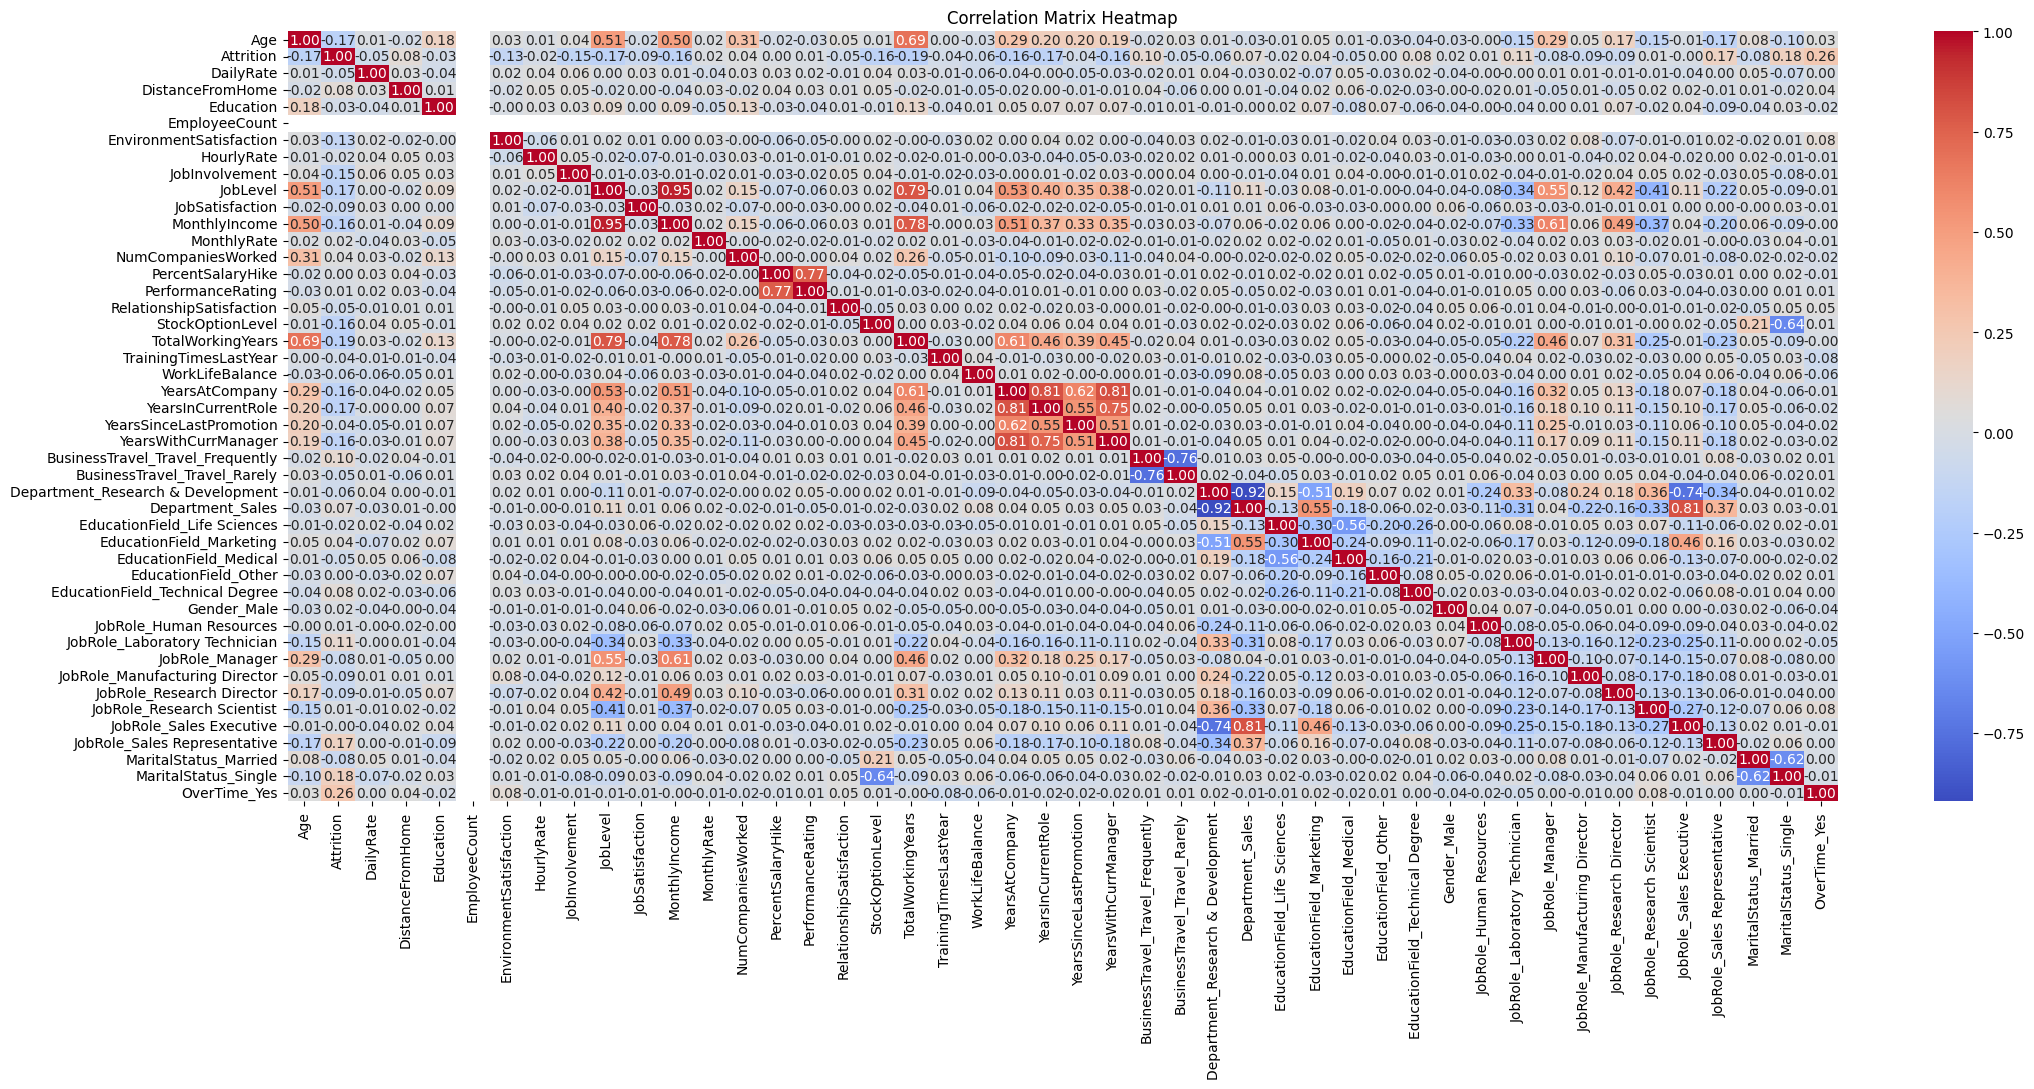

In [24]:
# Menghitung matriks korelasi
corr_matrix = df_encoded.corr()

# Membuat heatmap
plt.figure(figsize=(25, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")

### Menyiapkan fitur dan target

mempersiapkan dataset untuk analisis atau pemodelan machine learning dengan memisahkan fitur (X) dan target (y). X berisi semua variabel kecuali Attrition, sedangkan y hanya berisi Attrition sebagai target yang akan diprediksi.

In [25]:
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

### Train Test Split
Menggunakan library train_test_split() untuk membagi dataset menjadi data latih (X_train, y_train) dan data uji (X_test, y_test).

Menggunakan 20% sebagai data uji, dengan 80% data test

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
print(f"Jumlah data latih: {X_train.shape[0]}")
print(f"Jumlah data uji: {X_test.shape[0]}")

Jumlah data latih: 846
Jumlah data uji: 212


In [28]:
print(f"Jumlah data latih (X_train): {X_train.shape[0]}")
print(f"Jumlah data latih (y_train): {y_train.shape[0]}")

Jumlah data latih (X_train): 846
Jumlah data latih (y_train): 846


In [29]:
print(y_train.value_counts())

Attrition
0    703
1    143
Name: count, dtype: int64


### Melakukan resampling data
Menggunakan SMOTE untuk menangani ketidakseimbangan kelas. Dalam tahapan ini oversampling akan dilakukan pada data latih sehingga jumlah sampel dari kelas minoritas (Attrition = 1) menjadi seimbang dengan kelas mayoritas.

Hasilnya menunjukkan bahwa setelah resampling, jumlah sampel dari kedua kelas menjadi 703, sehingga model memiliki data yang lebih seimbang untuk pelatihan.

In [30]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [31]:
print(y_resampled.value_counts())

Attrition
0    703
1    703
Name: count, dtype: int64


### Normalisasi - Standard Scaler
Tahapan normalisasi ini berguna dalam memastikan bahwa fitur memiliki skala yang seragam sebelum masuk ke tahap pemodelan. Prosesnya ini melibatkan pustaka StandardScaler dari Sklearn, dengan melakukan fit dan transformasi pada data training serta menerapkan transformasi pada data uji

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_resampled) 
X_test_scaled = scaler.transform(X_test)     

## Modeling

### Pelatihan model
Dalam proses ini akan dilakukan pelatihan model menggunakan algoritma logistic regression yang dibuat dengan batas iterasi max. 1000 dan dilatih menggunakan data training yang sudah disiapkan saat data preparation yaitu X_train_scaled dan y_resampled untuk label - label yang telah dilakukan resample

In [33]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_resampled)  

LogisticRegression(max_iter=1000)

## Evaluation

### Evaluasi Model
Prediksi akan dilakukan pada data uji (X_test_scaled) dengan hasil evaluasi yang ditampilkan menggunakan conffusion matrix untuk menganalisis performa model serta melakukan perhitungan ROC AUC Score (dihitung menggunakan probabilitas hasil prediksi). ROC AUC Score akan menunjukan seberapa baik model membedakan antara kelas positif dan negatif. Lalu menampilkan hasil classification report dari pelatihan yang telah dilakukan

In [34]:
y_pred = model.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1]))

[[157  19]
 [ 18  18]]
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       176
           1       0.49      0.50      0.49        36

    accuracy                           0.83       212
   macro avg       0.69      0.70      0.69       212
weighted avg       0.83      0.83      0.83       212

ROC AUC Score: 0.7842487373737373


Berdasrarkan confusion matrix: 

```
[[157  19]
 [ 18  18]]
```

- model mampu mengklasifikasikan kelas negatif dengan benar (baris pertama) sebanyak 157 sample, lalu untuk kelas negatif dengan salah ada 19 sample
- pada baris kedua, model mampu mengklasifikasikan 18 sample positif, dengan 18 sample diklasifikasikan sebagai negatif

Bedasarkan classification report:

```
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       176
           1       0.49      0.50      0.49        36

  accuracy                           0.83       212
 macro avg       0.69      0.70      0.69       212
weighted avg       0.83      0.83      0.83       212

```

**Precision** menunjukkan seberapa akurat model saat memprediksi kelas tertentu. Kelas 0 (negatif) memiliki precision yang lebih tinggi dibandingkan kelas 1 (positif).

**Recall** menunjukkan kemampuan model dalam menemukan semua contoh dari suatu kelas. Kelas 1 (positif) memiliki recall yang lebih rendah.

**F1-score** adalah kombinasi precision dan recall, yang menunjukkan keseimbangan antara keduanya.

**Akurasi** keseluruhan model adalah 83%, yang berarti model cukup baik dalam mengklasifikasikan data.

**Skor ROC AUC** menunjukan kemampuan model dalam membedakan kelas negatif dan positif. Model memiliki nilai 0.784 yang menandakan bahwa model memiliki performa yang cukup baik (tetapi dapat ditingkatkan lagi)

---
### Analisis Koefisien Model
Hal ini dilakukan untuk mengurutkan dan menampilkan fitur berdasarkan pengaruhnya terhadap hasil prediksi

In [35]:
coeff_df = pd.DataFrame(model.coef_[0], index=X.columns, columns=['Coefficient'])
coeff_df.sort_values(by='Coefficient', ascending=False)

,Coefficient
OverTime_Yes,0.792681
MonthlyIncome,0.693491
YearsAtCompany,0.491084
NumCompaniesWorked,0.395209
YearsSinceLastPromotion,0.387708
DistanceFromHome,0.236602
MonthlyRate,0.122731
BusinessTravel_Travel_Frequently,0.096529
EmployeeCount,0.000000
Gender_Male,-0.017271


Berdasarkan hasil diatas, Koefisien - koefisien ini menunjukkan seberapa besar dan ke arah mana hubungan antara setiap fitur dengan variabel target. Beberapa variabel memiliki pengaruh positif, sementara yang lain negatif

Misalnya, "OverTime_Yes" memiliki koefisien tertinggi, yang berarti bekerja lembur sangat berpengaruh terhadap hasil yang diprediksi oleh model. Sebaliknya, "PerformanceRating" memiliki koefisien negatif, menunjukkan bahwa meningkatnya rating kinerja mungkin berhubungan dengan penurunan dalam variabel target.

### Dataframe hasil prediksi
Menggabungkan hasil prediksi ke dalam dataframe untuk dianalisis lebih lanjut serta menyertakan label aktual, prediksi model, dan probabilitas attrition

In [36]:
results_df = X_test.copy()
results_df['Actual_Attrition'] = y_test.values
results_df['Predicted_Attrition'] = y_pred
results_df['Attrition_Probability'] = model.predict_proba(X_test_scaled)[:, 1]

In [37]:
# Tampilkan data
results_df

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,Actual_Attrition,Predicted_Attrition,Attrition_Probability
958,38,130,2,1,1,3,32,2,2,1,...,0,0,1,0,0,1,0,0,0,0.334885
824,43,531,4,3,1,3,56,1,2,3,...,0,0,1,0,0,1,0,0,0,0.065854
1180,40,1479,24,2,1,1,100,3,3,1,...,0,0,1,0,0,1,1,1,0,0.246642
613,36,541,3,3,1,0,48,1,2,3,...,0,0,1,0,1,0,0,0,0,0.076779
761,38,330,17,0,1,2,65,1,2,2,...,0,0,0,0,1,0,0,0,0,0.141645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1098,42,201,1,3,1,1,95,2,0,0,...,0,0,0,0,0,0,0,0,0,0.203462
1258,40,523,2,2,1,2,98,2,1,3,...,0,1,0,0,0,1,0,0,0,0.016203
286,35,538,25,1,1,0,54,1,1,3,...,0,0,0,0,0,1,0,0,0,0.330844
181,39,1485,25,1,1,2,71,2,2,2,...,0,0,0,0,1,0,0,0,0,0.052104


### Akurasi prediksi model
Pada proses ini akan menghitung akurasi prediksi menggunakan accuracy_score dari sklearn.metrics dan menampilkan subset DataFrame results_df yang berisi data dengan Predicted_Attrition == 1.

Hasilnya menunjukkan akurasi prediksi sebesar 82.55%, serta daftar individu dengan beberapa atribut seperti tingkat keterlibatan, level pekerjaan, kepuasan kerja, peran di perusahaan, status pernikahan, dan apakah mereka bekerja lembur.

In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(results_df['Actual_Attrition'], results_df['Predicted_Attrition'])
print(f"Akurasi Prediksi: {accuracy:.2%}")

Akurasi Prediksi: 82.55%


In [39]:
from IPython.display import display
display(results_df[results_df['Predicted_Attrition'] == 1])


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,Actual_Attrition,Predicted_Attrition,Attrition_Probability
100,21,251,10,1,1,0,45,1,0,2,...,0,0,0,0,0,1,0,1,1,0.902588
346,26,496,11,1,1,0,60,2,1,0,...,0,0,0,0,1,0,1,0,1,0.928201
622,26,192,1,1,1,0,59,1,0,0,...,0,0,0,0,1,0,0,0,1,0.565645
1100,30,413,7,0,1,3,57,2,0,1,...,0,0,0,1,0,1,0,0,1,0.545894
1240,40,720,16,3,1,0,51,1,1,2,...,0,0,0,0,0,1,0,0,1,0.552049
289,37,807,6,3,1,2,63,2,0,0,...,0,0,0,0,0,0,1,1,1,0.628472
322,37,1252,19,1,1,0,32,2,2,1,...,0,0,1,0,0,1,1,0,1,0.689298
228,25,867,19,1,1,2,36,1,0,1,...,0,0,0,1,1,0,1,1,1,0.763140
10,25,583,4,0,1,2,87,1,1,0,...,0,0,1,0,1,0,0,0,1,0.627633
951,58,390,1,3,1,3,32,0,1,2,...,0,0,0,0,0,0,1,0,1,0.541703


Berdasarkan hasil pelatihan didapatkan beberapa temuan seperti:

#### Evaluasi Performa Model
Akurasi sebesar 83% cukup baik, tetapi ada ketidakseimbangan dalam prediksi untuk kelas positif (attrition). Meskipun model sudah cukup baik dalam mengidentifikasi pegawai yang tidak keluar, kemampuannya dalam mendeteksi pegawai yang akan keluar masih lemah (precision dan recall rendah untuk kelas 1).

ROC AUC sebesar 0.784 menunjukkan bahwa model memiliki kemampuan cukup baik dalam membedakan pegawai yang akan keluar dan yang tetap bertahan, tetapi masih bisa ditingkatkan dengan optimasi fitur atau model yang lebih kompleks.

#### Analisis Attrition
OverTime memiliki dampak signifikan terhadap kemungkinan pegawai keluar, menunjukkan bahwa pegawai yang sering lembur memiliki tingkat attrition lebih tinggi.

Performance Rating yang tinggi ternyata berkorelasi negatif dengan attrition, mungkin karena pegawai dengan performa tinggi justru memiliki lebih banyak kesempatan di luar organisasi sehingga lebih cenderung keluar.

Faktor-faktor lain seperti kepuasan kerja dan tingkat keterlibatan juga memainkan peran dalam keputusan pegawai untuk bertahan atau keluar.

#### Rekomendasi Strategis
- Meningkatkan Retensi Pegawai
- Memberikan insentif atau keseimbangan kerja bagi pegawai yang sering lembur agar mereka tetap bertahan.
- Mengeksplorasi kepuasan kerja lebih lanjut untuk memahami aspek yang bisa ditingkatkan demi retensi yang lebih tinggi.
- Optimasi Model
- Mungkin perlu penyesuaian algoritma atau teknik balancing data agar model lebih baik dalam mengidentifikasi pegawai yang benar-benar berisiko keluar.
- Mencoba teknik seperti oversampling pada data attrition untuk meningkatkan pemahaman model terhadap kelas 1.